11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9236 - loss: 0.2574 - val_accuracy: 0.9628 - val_loss: 0.1202
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9671 - loss: 0.1062 - val_accuracy: 0.9725 - val_loss: 0.0950
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9768 - loss: 0.0747 - val_accuracy: 0.9765 - val_loss: 0.0900
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9823 - loss: 0.0561 - val_accuracy: 0.9775 - val_loss: 0.0780
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9856 - loss: 0.0441 - val_accuracy: 0.9783 - val_loss: 0.0821
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.0800

Test Accuracy: 0.9758999943733215
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<Figure size 1000x800 with 0 Axes>

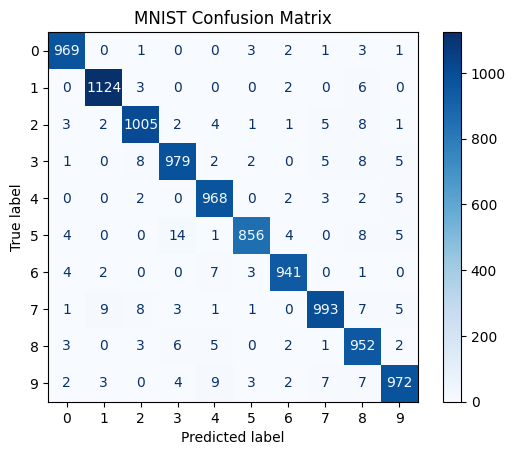

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Load and Preprocess Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# 2. Build DNN Architecture
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_acc)

# Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)
disp.plot(cmap='Blues')
plt.title("MNIST Confusion Matrix")
plt.show()

Total Misclassified Images: 241


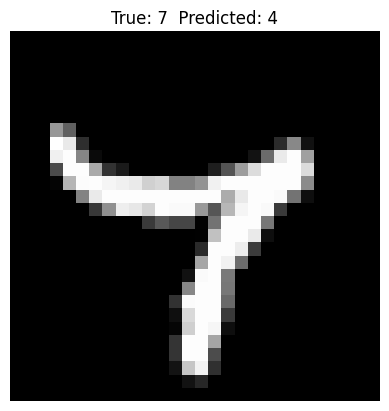

Image ID: 124, True Label: 7, Predicted Label: 4


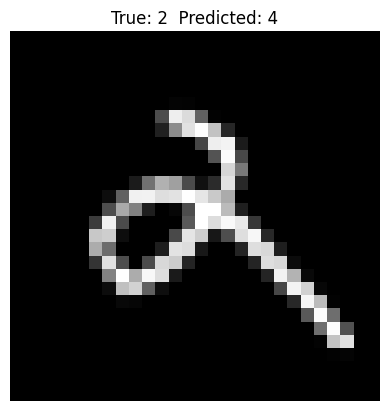

Image ID: 149, True Label: 2, Predicted Label: 4


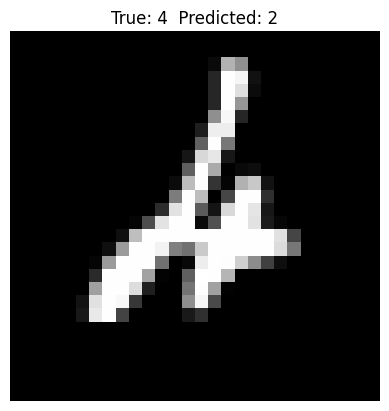

Image ID: 247, True Label: 4, Predicted Label: 2


In [2]:
misclassified = np.where(y_pred != y_test)[0]

print("Total Misclassified Images:", len(misclassified))

for i in range(3):
    idx = misclassified[i]

    plt.imshow(x_test[idx], cmap='gray')
    plt.title(
        f"True: {y_test[idx]}  Predicted: {y_pred[idx]}"
    )
    plt.axis('off')
    plt.show()

    print(
        f"Image ID: {idx}, "
        f"True Label: {y_test[idx]}, "
        f"Predicted Label: {y_pred[idx]}"
    )

In [3]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy*100)
print("Precision:", precision*100)
print("Recall   :", recall*100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy : 97.59
Precision: 97.59954785344736
Recall   : 97.59
